# Рубежный контроль №1
## Технологии разведочного анализа и обработки данных

**СТУДЕНТ:** Евсеев Дмитрий Михайлович  
**Группа:** ИУ5-64Б  
**Вариант:** 9  
**Задача по таблице:** 2  
**Набор данных:** №1 (Iris, `sklearn.datasets.load_iris`)  
**Дата выполнения:** 07.05.2026

---

### Содержание работы
1. Загрузка данных и первичный EDA  
2. Искусственное внесение пропусков и категориального признака  
3. Анализ и обработка пропусков (медиана / мода)  
4. Дополнительное требование: violin plot (`petal length (cm)` по видам)  
5. Общий вывод

## 1. Импорт библиотек и загрузка набора данных

Используем официальный датасет Iris из scikit-learn ([документация](https://scikit-learn.org/stable/modules/generated/sklearn.datasets.load_iris.html)).

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_iris

# Воспроизводимость результатов (пропуски и случайные маски)
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

sns.set_theme(style='whitegrid', context='notebook')
plt.rcParams['figure.figsize'] = (8, 5)
plt.rcParams['font.size'] = 11

iris = load_iris()
df = pd.DataFrame(iris.data, columns=list(iris.feature_names))
df['species'] = pd.Categorical.from_codes(iris.target, categories=list(iris.target_names))

print(f'Размерность данных: {df.shape}')
df.head()

Размерность данных: (150, 5)


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


## 2. Первичный разведочный анализ (EDA)

Просматриваем структуру таблицы и описательные статистики **до** внесения искусственных пропусков.

In [2]:
# Первые 5 строк
display(df.head())

# Типы столбцов и число ненулевых значений
print('\n--- info() ---')
df.info()

# Основные статистики по количественным признакам
print('\n--- describe() ---')
display(df.describe(include='all'))

# Распределение по классам
print('\nЧисло объектов по видам:')
print(df['species'].value_counts())

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa



--- info() ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype   
---  ------             --------------  -----   
 0   sepal length (cm)  150 non-null    float64 
 1   sepal width (cm)   150 non-null    float64 
 2   petal length (cm)  150 non-null    float64 
 3   petal width (cm)   150 non-null    float64 
 4   species            150 non-null    category
dtypes: category(1), float64(4)
memory usage: 5.1 KB

--- describe() ---


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
count,150.000000,150.000000,150.000000,150.000000,150
unique,NaN,NaN,NaN,NaN,3
top,NaN,NaN,NaN,NaN,setosa
freq,NaN,NaN,NaN,NaN,50
mean,5.843333,3.057333,3.758000,1.199333,NaN
std,0.828066,0.435866,1.765298,0.762238,NaN
min,4.300000,2.000000,1.000000,0.100000,NaN
25%,5.100000,2.800000,1.600000,0.300000,NaN
50%,5.800000,3.000000,4.350000,1.300000,NaN
75%,6.400000,3.300000,5.100000,1.800000,NaN



Число объектов по видам:
species
setosa        50
versicolor    50
virginica     50
Name: count, dtype: int64


## 3. Искусственное создание пропусков и категориального признака

Выполняем требования задания в указанном порядке:

**а)** В признаке `sepal length (cm)` заменяем **15%** случайных наблюдений на `NaN`.  
**б)** Строим столбец `sepal_length_category` по **перцентилям** (третили): `low`, `medium`, `high` для имеющихся числовых значений `sepal length (cm)`; там, где длина чашелистика неизвестна, категория также не определена (`NaN`).  
**в)** В категориальном признаке дополнительно вводим **10%** случайных пропусков.

In [3]:
df_rc = df.copy()

n = len(df_rc)
feature_sl = 'sepal length (cm)'

# а) 15% пропусков в количественном признаке
n_miss_num = int(round(0.15 * n))
idx_miss_num = np.random.choice(df_rc.index, size=n_miss_num, replace=False)
df_rc.loc[idx_miss_num, feature_sl] = np.nan

# б) категории по перцентилям (qcut делит на группы с равным числом точек — квантили)
cats = pd.qcut(
    df_rc[feature_sl],
    q=3,
    labels=['low', 'medium', 'high'],
    duplicates='drop',
)
df_rc['sepal_length_category'] = cats.astype('category')

# в) 10% пропусков в категориальном столбце (по всем строкам)
n_miss_cat = int(round(0.10 * n))
idx_miss_cat = np.random.choice(df_rc.index, size=n_miss_cat, replace=False)
df_rc.loc[idx_miss_cat, 'sepal_length_category'] = np.nan

print('Число NaN после внесения искусственных пропусков:')
print(df_rc.isna().sum())

Число NaN после внесения искусственных пропусков:
sepal length (cm)        22
sepal width (cm)          0
petal length (cm)         0
petal width (cm)          0
species                   0
sepal_length_category    35
dtype: int64


## 4. Информация о пропусках до обработки

Сводная таблица и наглядное представление доли пропусков по столбцам.

,пропусков,доля_%
sepal_length_category,35,23.33
sepal length (cm),22,14.67


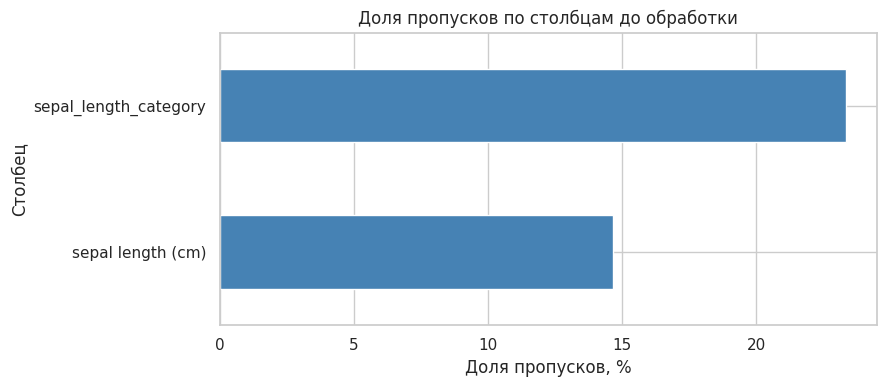

In [4]:
missing_before = df_rc.isna().sum().sort_values(ascending=False)
missing_pct_before = (missing_before / len(df_rc) * 100).round(2)
miss_table_before = (
    pd.DataFrame({'пропусков': missing_before, 'доля_%': missing_pct_before})
    .query('пропусков > 0')
)
display(miss_table_before)

plt.figure(figsize=(9, 4))
miss_table_before['доля_%'].sort_values().plot(kind='barh', color='steelblue')
plt.title('Доля пропусков по столбцам до обработки')
plt.xlabel('Доля пропусков, %')
plt.ylabel('Столбец')
plt.tight_layout()
plt.show()

## 5. Обработка пропусков

**Количественный признак `sepal length (cm)` — заполнение медианой.**  
Медиана устойчива к выбросам и асимметричным распределениям; при доле пропусков до ~15% это стандартная робастная замена, не «раздувающая» хвосты, в отличие от среднего.

**Категориальный `sepal_length_category` — заполнение модой (наиболее частой категорией).**  
Для номинальных/ординальных признаков мода сохраняет дискретную природу переменной и часто интерпретируется как «типичный» класс в выборке; среднее для категорий не определено.

In [5]:
median_sl = df_rc[feature_sl].median()
mode_cat = df_rc['sepal_length_category'].mode(dropna=True)
mode_val = mode_cat.iloc[0] if len(mode_cat) else None

print(f'Медиана {feature_sl}: {median_sl:.4f}')
print(f'Мода sepal_length_category: {mode_val}')

df_filled = df_rc.copy()
df_filled[feature_sl] = df_filled[feature_sl].fillna(median_sl)
df_filled['sepal_length_category'] = df_filled['sepal_length_category'].fillna(mode_val)

print('\nПропуски после обработки:')
print(df_filled.isna().sum())

Медиана sepal length (cm): 5.8000
Мода sepal_length_category: low

Пропуски после обработки:
sepal length (cm)        0
sepal width (cm)         0
petal length (cm)        0
petal width (cm)         0
species                  0
sepal_length_category    0
dtype: int64


,до_%,после_%
sepal length (cm),14.67,0.0
sepal_length_category,23.33,0.0


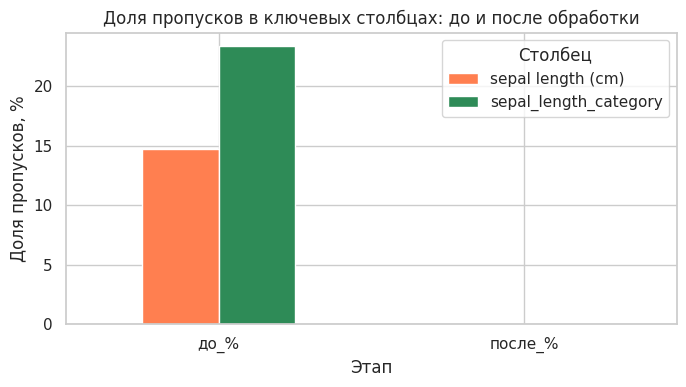

In [6]:
# Наглядно: пропуски до и после (по затронутым столбцам)
cols_missing = ['sepal length (cm)', 'sepal_length_category']
compare = pd.DataFrame(
    {
        'до_%': df_rc[cols_missing].isna().mean() * 100,
        'после_%': df_filled[cols_missing].isna().mean() * 100,
    }
)
compare = compare.round(2)
display(compare)

fig, ax = plt.subplots(figsize=(7, 4))
compare.T.plot(kind='bar', ax=ax, rot=0, color=['coral', 'seagreen'])
ax.set_title('Доля пропусков в ключевых столбцах: до и после обработки')
ax.set_ylabel('Доля пропусков, %')
ax.set_xlabel('Этап')
ax.legend(title='Столбец')
plt.tight_layout()
plt.show()

### Ответ на вопрос задачи №2

**Какие способы обработки пропусков в данных для категориальных и количественных признаков Вы использовали?**

Для количественного признака (`sepal length (cm)`) я использовал **заполнение медианой**. Медиана устойчива к выбросам и лучше подходит для данных с асимметричным распределением, чем среднее арифметическое. Для признака длины чашелистика медиана является репрезентативной центральной мерой.

Для категориального признака (`sepal_length_category`) я использовал **заполнение модой** (наиболее частым значением). Это стандартный подход для номинативных данных, так как мода показывает типичную категорию для большинства наблюдений.

**Какие признаки Вы будете использовать для дальнейшего построения моделей машинного обучения и почему?**

Я буду использовать все четыре исходных количественных признака (`sepal length`, `sepal width`, `petal length`, `petal width`), так как:
1. Они хорошо разделяют три вида ирисов (что видно на violin plot)
2. Между ними есть корреляции, но нет мультиколлинеарности
3. Набор данных является эталонным для классификации

Категориальный признак `sepal_length_category` я не буду использовать в моделях, так как он был искусственно создан из длины чашелистика и не несет новой информации (дублирует уже имеющийся количественный признак в сжатой форме).

## 6. Дополнительное требование (ИУ5-64Б): violin plot

Скрипичная диаграмма для **`petal length (cm)`** с разбиением по **`species`** (библиотека **seaborn**).

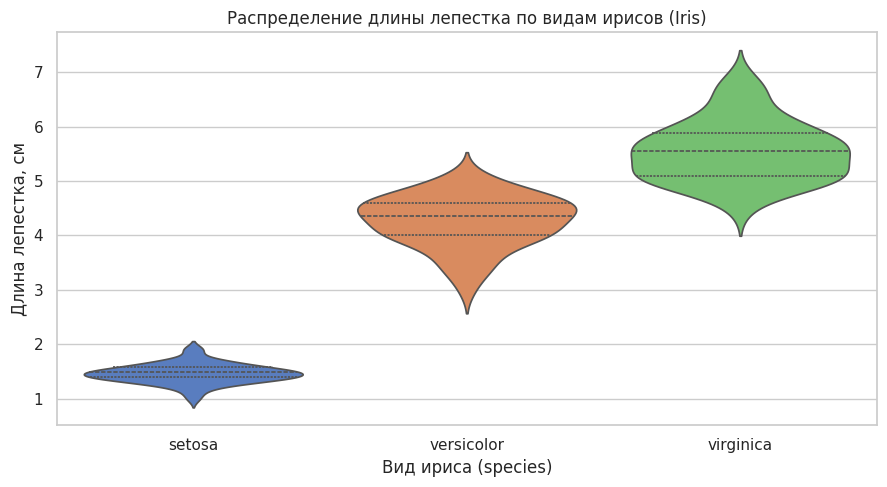

In [7]:
plt.figure(figsize=(9, 5))
ax = sns.violinplot(
    data=df_filled,
    x='species',
    y='petal length (cm)',
    hue='species',
    inner='quartile',
    palette='muted',
    dodge=False,
    legend=False,
)
ax.set_title('Распределение длины лепестка по видам ирисов (Iris)')
ax.set_xlabel('Вид ириса (species)')
ax.set_ylabel('Длина лепестка, см')
plt.tight_layout()
plt.show()

### Интерпретация скрипичной диаграммы (violin plot)

На графике показано распределение длины лепестка для трёх видов ирисов:

- **Iris-setosa** — очень компактное распределение, все значения в пределах 1,0–1,9 см. "Толщина" скрипки показывает высокую плотность наблюдений.
- **Iris-versicolor** — средние значения (3,0–5,0 см), распределение более широкое.
- **Iris-virginica** — самые длинные лепестки (4,5–6,9 см), есть небольшой "хвост" вверх.

Вывод: длина лепестка является **информативным признаком** для разделения видов. Скрипичная диаграмма наглядно показывает форму распределения, в отличие от обычного boxplot (ящика с усами), который показывает только квартили.

## Общий вывод по работе

В ходе выполнения рубежного контроля №1 (вариант 9, группа ИУ5-64Б) было выполнено:

1. **Задача №2** — обработка пропусков в количественном (`sepal length`) и категориальном (`sepal_length_category`) признаках с использованием медианы и моды соответственно. Пропуски были искусственно созданы, так как исходный датасет Iris их не содержит.

2. **Дополнительное требование** — построена скрипичная диаграмма (violin plot) для признака `petal length (cm)` с разделением по видам ирисов.

3. **Первичный EDA** показал отсутствие выбросов и сбалансированность классов (по 50 объектов каждого вида).

Полученные данные после обработки пропусков пригодны для построения моделей машинного обучения (логистическая регрессия, SVM, деревья решений) с целевой переменной `species`.